In [ ]:
%load_ext autoreload
%autoreload 2

from collections import defaultdict
import gc
from itertools import product
import json
import os
from pathlib import Path
import subprocess

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from notebook_utils.metrics import StepMetricsReader
from scaling_llms.constants import CKPT_FILES
from scaling_llms.data import get_dataloaders, DataLoaderConfig
from scaling_llms.experiments import build_raw_model, ExperimentRunner
from scaling_llms.models import GPTModel
from scaling_llms.registries import (
    make_dataset_registry,
    make_run_registry, 
    DatasetIdentity,
    MakeDatasetRegistryConfig,
    MakeRunRegistryConfig,
)
from scaling_llms.utils.loggers import setup_console_logging
from scaling_llms.utils.training import set_determinism

setup_console_logging()
load_dotenv()



True

In [2]:
DATASET_KWARGS = dict(
    dataset_name="Salesforce/wikitext",
    dataset_config="wikitext-103-raw-v1",
    train_split="train",
    eval_split="validation",
    tokenizer_name="gpt2_tiktoken",
    text_field="text"
)

CONSTANT_GPT_HPARAMS = dict(
    # --- Dimensions ---
    # n_embd TO DEFINE IN WIDTH-SWEEP BELOW
    n_layer=6,           # depth fixed throughout
    n_head=4,
    # --- MLP ---
    mlp_type="standard_gelu",
    mlp_bias=False,
    d_ff = None,  # will be set to 4*n_embd in GPTModel if None
    # --- Normalization ---
    norm_type="rmsnorm",
    # --- Positional Encoding ---
    pos_encoding_type="rotary",
    # --- Attention / LM head ---
    attn_bias=False,
    tied_embeddings=False,
    lm_head_bias=False,
   # --- Dropout ---
    attn_pdrop=0.0,
    resid_pdrop=0.0,
)


BASE_WIDTH = 128  # your proxy width
WIDTHS = [BASE_WIDTH, 256, 512, 1024, 2048]  # proxy + 4 transfer targets

# Tracking Registries

In [ ]:
LOCAL_ARTIFACTS_ROOT = Path("/workspace/artifacts/dev/")
REMOTE_ARTIFACTS_ROOT = Path("scaling-llms/dev/")
DATABASE_URL = os.environ.get("DATABASE_URL")

run_registry = make_run_registry(
    MakeRunRegistryConfig(
        table_name="dev_runs",
        artifacts_root=str(LOCAL_ARTIFACTS_ROOT / "runs"),
        database_url=DATABASE_URL,
        sync_hooks_type="rclone",
        sync_hooks_args=dict(
            remote_rclone_name="r2",
            remote_artifacts_root=str(REMOTE_ARTIFACTS_ROOT / "runs"),
            global_args=["--s3-no-check-bucket"],
        )
    )
)
dataset_registry = make_dataset_registry(
    MakeDatasetRegistryConfig(
        table_name="dev_datasets",
        artifacts_root=str(LOCAL_ARTIFACTS_ROOT / "datasets"),
        database_url=DATABASE_URL,
        sync_hooks_type="rclone",
        sync_hooks_args=dict(
            remote_rclone_name="r2",
            remote_artifacts_root=str(REMOTE_ARTIFACTS_ROOT / "datasets"),
            global_args=["--s3-no-check-bucket"],
        )
    )
)

# A. Coordinate Check

In [ ]:
def collect_activations(
    model: GPTModel,
    idx: torch.Tensor,
) -> dict[str, torch.Tensor]:
    """
    Run a single forward pass and collect mean absolute activations
    from selected layers for coord-check diagnostics.

    Important:
    - We DO NOT hook `lm_head` because μP scaling is applied AFTER it.
    - Instead, we manually record final logits after `_decode`.
    """

    # Layers we want to probe for activation scaling behavior
    COORD_CHECK_LAYERS = {
        "transformer.wte",        # embedding output
        "transformer.h.0.attn",   # first block attention
        "transformer.h.0.mlp",    # first block MLP
        "transformer.h.0",        # first block residual stream
        "transformer.h.2",        # mid-layer residual stream
        "transformer.h.5",        # late-layer residual stream
        "transformer.norm_f",     # final norm before logits
    }

    acts: dict[str, torch.Tensor] = {}  # stores activations per layer
    hooks = []  # store hook handles to remove later

    # Some modules return tuples → unwrap to tensor
    def _unwrap(out):
        return out[0] if isinstance(out, tuple) else out

    # Register forward hooks on selected modules
    for name, module in model.named_modules():
        if name not in COORD_CHECK_LAYERS:
            continue

        def _hook(m, inp, out, n=name):
            out = _unwrap(out)
            # Store mean absolute activation (simple scalar summary)
            acts[n] = out.detach().abs().mean()

        hooks.append(module.register_forward_hook(_hook))

    # Save current mode and switch to eval for deterministic behavior
    was_training = model.training
    model.eval()

    try:
        with torch.no_grad():
            # Forward pass split into encode/decode
            # so hooks capture internal activations correctly
            x = model._encode(idx)

            # Final logits AFTER μP scaling (critical!)
            logits = model._decode(x)

            # Record final output activations
            acts["logits"] = logits.detach().abs().mean()

    finally:
        # Always clean up hooks to avoid memory leaks
        for h in hooks:
            h.remove()

        # Restore original training mode
        model.train(was_training)

    return acts


def collect_activations_over_batches(
    model: GPTModel,
    batch_iterable,
    num_batches: int,
    device: str | torch.device,
) -> dict[str, torch.Tensor]:
    """
    Estimate expected activations by averaging over multiple batches.

    This reduces noise compared to using a single batch.
    """

    acts_accum = defaultdict(list)  # accumulate activations per layer

    for batch_idx, (x,_) in enumerate(batch_iterable):
        if batch_idx >= num_batches:
            break  # only use a fixed number of batches

        x = x.to(device)

        # Collect activations for this batch
        acts = collect_activations(model, x)

        # Accumulate per-layer activations
        for layer_name, act in acts.items():
            acts_accum[layer_name].append(act)

    # Average across batches → smoother, more reliable estimates
    return {
        layer_name: torch.stack(act_list).mean()
        for layer_name, act_list in acts_accum.items()
    }


def save_to_r2(step2records, save_name):
    serializable = {
        str(step): records
        for step, records in step2records.items()
    }
    remote_path = f"r2:{REMOTE_ARTIFACTS_ROOT}/coord_checks/{save_name}.json"
    subprocess.run(
        [
            "rclone",
            "rcat",
            remote_path,
            "--s3-no-check-bucket",
        ],
        input=json.dumps(serializable, indent=2).encode(),
        check=True,
    )


def run_coord_check(
    x,
    y,
    eval_dl,
    widths,
    seeds,
    use_mup,
    seq_len,
    vocab_size,
    lr,
    num_steps,
    num_eval_batches,
):
    """
    Main coord-check loop.

    Procedure:
    - Train each model (different widths) on SAME batch
    - Measure activations on MULTIPLE eval batches
    - Aggregate across seeds
    """

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Training batch (fixed across widths for controlled comparison)
    x = x.to(device)
    y = y.to(device)

    step2records = defaultdict(list)

    # Loop over model widths
    for width in tqdm(widths, desc="width"):
        layer_name_step2act_list = defaultdict(list)

        # Loop over random seeds (reduce variance)
        for seed in tqdm(seeds, desc="seed", leave=False):
            set_determinism(seed)

            # Initialize model
            gpt_hparams = dict(
                n_embd=width,
                mup_base_width=BASE_WIDTH if use_mup else None,
                **CONSTANT_GPT_HPARAMS,
            )
            model = build_raw_model(
                seq_len=seq_len,
                vocab_size=vocab_size,
                gpt_hparams=gpt_hparams,
            ).to(device)

            # Create optimizer with μP-aware param groups
            params = model.get_param_groups(base_lr=lr, weight_decay=0.0)
            optimizer = torch.optim.AdamW(params, betas=(0.9, 0.95))

            # Train for a few steps
            for step in tqdm(range(num_steps), desc="step", leave=False):
                model.train()

                # Measure layer activations on MULTIPLE eval batches
                acts = collect_activations_over_batches(
                    model=model,
                    batch_iterable=eval_dl,
                    num_batches=num_eval_batches,
                    device=device,
                )

                # Store activations per layer and step
                for layer_name, act in acts.items():
                    layer_name_step2act_list[(layer_name, step)].append(act)

                if step == num_steps - 1:
                    break  # skip optimization step on last iter

                # Optimize on FIXED training batch
                optimizer.zero_grad()
                out = model(x, y)
                out.loss.backward()
                optimizer.step()

        # Aggregate across seeds -> final statistics
        for (layer_name, step), act_list in layer_name_step2act_list.items():
            step2records[step].append(
                dict(
                    width=width,
                    layer_name=layer_name,
                    mean_abs_act=torch.stack(act_list).mean().item(),
                )
            )
            
    # Save to R2
    save_name = f"coord_check_{'with_mup' if use_mup else 'without_mup'}"
    save_to_r2(step2records, save_name)

    return step2records

In [ ]:
# Fetch dataloaders for coordinate check
dl_config = DataLoaderConfig(
    seq_len=512,
    train_batch_size=16,
    eval_batch_size=16,
    start_sample_idx=0,
    seed=42
)
dls = get_dataloaders(
    dataset_id=DatasetIdentity(**DATASET_KWARGS),
    dataset_registry=dataset_registry,
    dataloader_config=dl_config,
)

# Fix a training batch for the coord check (same across widths)
train_batch = next(iter(dls["train"]))

del dls["train"] 
gc.collect();  # free up memory since we won't use it anymore

In [ ]:
# Run the coordinate check experiment for both standard parameterization and μP
kwargs = dict(
    x=train_batch[0],
    y=train_batch[1],
    eval_dl=dls["eval"],
    widths=WIDTHS,
    seeds=[1, 12, 123, 1234, 12345],
    seq_len=dl_config.seq_len,
    vocab_size=dls["info"]["vocab_size"],
    lr=1e-3,
    num_steps=5,
    num_eval_batches=5,
)

step2records_sp = run_coord_check(**kwargs, use_mup=False)
step2records_mup = run_coord_check(**kwargs, use_mup=True)

In [ ]:
def plot_sp_mup_rows(step2records_sp, step2records_mup, steps_to_plot=None):

    steps = steps_to_plot or list(step2records_sp.keys())
    n_cols = len(steps)

    dfs_sp  = [pd.DataFrame(d) for d in step2records_sp.values()]
    dfs_mup = [pd.DataFrame(d) for d in step2records_mup.values()]

    for df in dfs_sp + dfs_mup:
        df["log2_width"] = np.log2(df["width"])

    # ── figure layout ────────────────────────────────────────
    fig, axes = plt.subplots(
        2, n_cols,
        figsize=(5 * n_cols, 8),
        sharey="row",           # share y within each row
        sharex=True,
    )
    # ensure axes is always 2-D
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    row_labels = ["SP", "μP"]
    all_dfs    = [dfs_sp, dfs_mup]

    # ── colour map: one colour per layer, consistent across panels ──
    all_layers = pd.concat(dfs_sp + dfs_mup)["layer_name"].unique()
    cmap       = plt.get_cmap("tab10")
    colour     = {layer: cmap(i % 10) for i, layer in enumerate(all_layers)}

    # ── plot ─────────────────────────────────────────────────
    for row_idx, (row_dfs, row_label) in enumerate(zip(all_dfs, row_labels)):
        for col_idx, (df, step) in enumerate(zip(row_dfs, steps)):
            ax = axes[row_idx, col_idx]

            for layer, grp in df.groupby("layer_name"):
                grp = grp.sort_values("log2_width")
                ax.plot(
                    grp["log2_width"],
                    grp["mean_abs_act"],
                    marker="o",
                    markersize=4,
                    linewidth=1.5,
                    color=colour[layer],
                    label=layer if (row_idx == 0 and col_idx == 0) else None,
                )

            # column title on top row only
            if row_idx == 0:
                ax.set_title(f"Step {step}", fontsize=11, fontweight="bold")

            # row label on leftmost column
            if col_idx == 0:
                ax.set_ylabel(f"{row_label}\nmean |act|", fontsize=10)

            # x-axis ticks: 2^k labels
            tick_vals = list(range(
                int(df["log2_width"].min()),
                int(df["log2_width"].max()) + 1
            ))
            ax.set_xticks(tick_vals)
            ax.set_xticklabels([f"$2^{{{k}}}$" for k in tick_vals], fontsize=9)
            ax.set_xlabel("width", fontsize=9)
            ax.grid(True, linestyle="--", alpha=0.4)
            ax.spines[["top", "right"]].set_visible(False)

    # ── legend (top-right of first subplot) ──────────────────
    axes[0, 0].legend(
        title="layer",
        fontsize=8,
        title_fontsize=9,
        loc="upper right",
        framealpha=0.8,
        edgecolor="0.8",
    )

    fig.suptitle(
        "SP vs μP: mean |activation| vs width across steps",
        fontsize=13,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()
    return fig

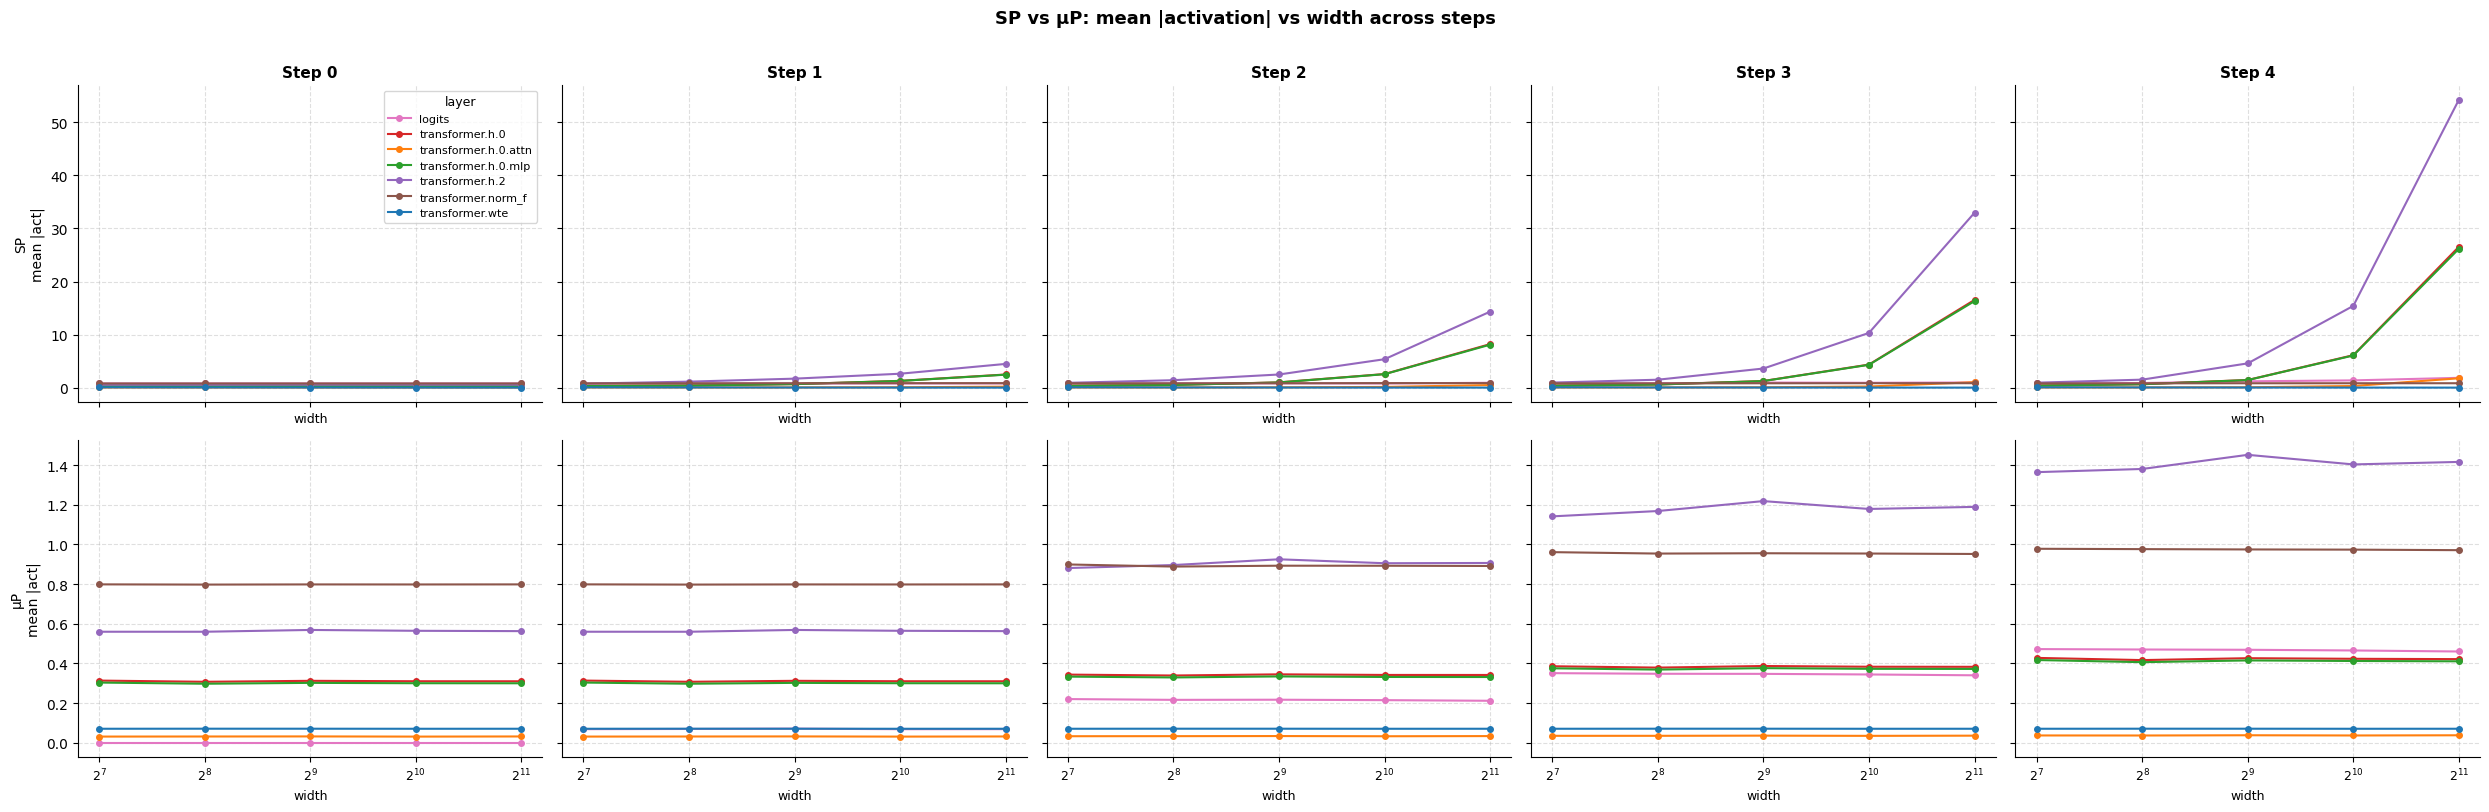

In [ ]:
fig = plot_sp_mup_rows(step2records_sp, step2records_mup, steps_to_plot=None)

In [ ]:
del dls
gc.collect();  

# B. Loss vs LR

In [ ]:
DATALOADER_KWARGS = dict(
    seq_len=1024,
    train_batch_size=32,
    eval_batch_size=None,
    start_sample_idx=0,
    seed=42
)

CONSTANT_TRAINER_ARGS = dict(
    num_steps=200, 
    beta1=0.9,
    beta2=0.95,
    weight_decay=0.0,
    precision="bf16",
    accum_steps=1,
    grad_clip_norm=1.0,
    device="auto",
    use_compile=False,
    local_rank=0,
    seed=42, # same seed for all runs
    iter_mode="infinite",
    lr_schedule=None,
    warmup_steps=0,
    min_lr_ratio=0.0,
    enable_tb=False,
    net_log_freq=20,
    sys_log_freq=-1,
    eval_log_freq=-1,
    ckpt_log_freq=-1,
    keep_last_n=None,
    best_eval_nll_tol=1e-4,
    enable_cuda_timer=False,
)

LOG2LRS = np.linspace(-13, -1, 8, endpoint=False)

In [ ]:
EXPERIMENT_NAME = "mup_test"
exp_runner = ExperimentRunner(
    exp_name=EXPERIMENT_NAME,
    run_registry=run_registry,
    dataset_registry=dataset_registry,
)

In [ ]:
for use_mup, width, log2lr in product([False, True], WIDTHS, LOG2LRS):
    # Prepare unique args
    run_name = "_".join([
        "mup" if use_mup else "sp",
        f"width={width}",
        f"log2lr={log2lr}",
    ])
    gpt_hparams=dict(
        n_embd=width,
        mup_base_width=BASE_WIDTH if use_mup else None,
        **CONSTANT_GPT_HPARAMS,
    )
    trainer_kwargs = dict(**CONSTANT_TRAINER_ARGS, lr=2**log2lr)

    # Execute run
    exp_runner.start(
        run_name=run_name,
        gpt_hparams=gpt_hparams,
        trainer_kwargs=trainer_kwargs,
        dataset_kwargs=DATASET_KWARGS,
        dataloader_kwargs=DATALOADER_KWARGS,
        overwrite=True,
    )

In [ ]:
run_names = run_registry.get_runs_as_df(experiment_name=EXPERIMENT_NAME)["run_name"].tolist()
for run_name in run_names:
    exp_runner.resume(
        run_name=run_name,
        ckpt_filename=CKPT_FILES.last_ckpt,
        max_steps=455
    )

In [4]:
smr = StepMetricsReader(run_registry, experiment_name="mup_test")

In [ ]:
mup_rows = []
sp_rows = []
for run_name in smr.list_run_names():
    try:
        tmp_df = smr.get_metrics_df(run_name, "train", "nll", "train", "lr")
        tmp_df["width"] = int(run_name.split("_")[1].split("=")[1])
        tmp_df["log2lr"] = tmp_df["lr"].apply(lambda x: np.log2(x))
        tmp_df = tmp_df.groupby(["log2lr", "width"], as_index=False)[["nll"]].min()
        if run_name.startswith("mup"):
            mup_rows.append(tmp_df)
        else:
            sp_rows.append(tmp_df)
    except Exception as e:
        print(f"Error processing {run_name}: {e}")
        break

df_mup = pd.concat(mup_rows)
df_sp = pd.concat(sp_rows)

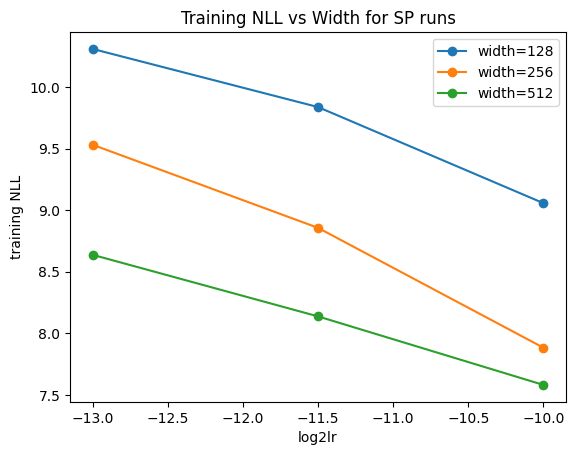

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 12), sharex=True)

for ax,df in zip(axs, [df_sp, df_mup]):
    for width, g in df.groupby("width"):
        g = g.sort_values("log2lr")
        ax.plot(
            g["log2lr"],
            g["nll"],
        marker="o",
        label=f"width={width}",
    )

# ax.set_xscale("log")
axs[0].set_title("Training NLL vs Log2LR for SP runs")
axs[0].set_xlabel("log2lr")
axs[0].set_ylabel("training NLL")
axs[0].legend()
axs[1].set_title("Training NLL vs Log2LR for MUP runs")
axs[1].set_xlabel("log2lr")
axs[1].set_ylabel("training NLL")
axs[1].legend()
plt.show()